In [1]:
# Understat xG Analysis for Attacking Players

"""Run the league stats script and visualise attacking players' xG and xGChain
per minute over the last 5 seasons, including a line of best fit.

This notebook assumes:
- `src/understat_league_stats.py` exists one level up from this notebook
- The script writes `<league_code>_players_<season>.csv` into the project root
- You have `pandas`, `matplotlib`, `seaborn`, and `plotly` installed
  (see `requirements.txt`).
"""

from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Make plots a bit prettier by default
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT  # league script writes CSVs into the project root
SRC_DIR = PROJECT_ROOT / "src"


In [2]:
# Parameters

# Leagues to analyse – must match the league codes used
# in `src/understat_league_stats.py`.
LEAGUE_CODES = ["EPL", "La_liga", "Bundesliga", "Serie_A", "Ligue_1"]

# This should match `SEASON_START_YEAR` in `src/understat_league_stats.py`
SEASON_START_YEAR = 2025

# Number of seasons (including SEASON_START_YEAR) to include
N_SEASONS = 5

seasons = list(range(SEASON_START_YEAR, SEASON_START_YEAR - N_SEASONS, -1))
seasons, LEAGUE_CODES

[2025, 2024, 2023, 2022, 2021]

In [3]:
# Run the league stats script to (re)generate CSVs

import runpy

league_script_path = SRC_DIR / "understat_league_stats.py"
print(f"Running {league_script_path} ...")
runpy.run_path(str(league_script_path))
print("Done.")

Running /Users/markdavis/Projects/soccer-stats/src/understat_league_stats.py ...
Done.


In [4]:
# Load and combine player data for all selected leagues and seasons

player_dfs = []

for league_code in LEAGUE_CODES:
    for season in seasons:
        csv_path = DATA_DIR / f"{league_code}_players_{season}.csv"
        print(f"Loading {csv_path} ...")
        df = pd.read_csv(csv_path)
        df["season"] = season
        df["league"] = league_code
        player_dfs.append(df)

players = pd.concat(player_dfs, ignore_index=True)
print(f"Combined players shape: {players.shape}")
players.head()

Loading /Users/markdavis/Projects/soccer-stats/EPL_players_2025.csv ...
Loading /Users/markdavis/Projects/soccer-stats/EPL_players_2024.csv ...
Loading /Users/markdavis/Projects/soccer-stats/EPL_players_2023.csv ...
Loading /Users/markdavis/Projects/soccer-stats/EPL_players_2022.csv ...
Loading /Users/markdavis/Projects/soccer-stats/EPL_players_2021.csv ...
Combined players shape: (2735, 19)


,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup,season
0,8260,Erling Haaland,26,2169,22,21.904284,6,4.323697,92,19,1,0,F S,Manchester City,19,18.859608,23.772826,3.301901,2025
1,13222,Thiago,26,2212,17,18.374264,1,2.371154,61,14,5,0,F S,Brentford,11,13.046082,16.014959,2.890031,2025
2,11363,Antoine Semenyo,25,2250,13,9.511308,4,2.991685,59,29,6,0,F M,"Bournemouth,Manchester City",12,7.988970,12.810340,3.261103,2025
3,5555,Dominic Calvert-Lewin,23,1671,10,10.760022,1,1.317244,45,13,1,0,F S,Leeds,8,9.237684,11.817670,1.887144,2025
4,8272,João Pedro,26,1913,10,9.348644,4,3.503022,45,24,3,0,F M S,Chelsea,10,9.348644,12.301924,3.428458,2025


In [5]:
# Filter to attacking players

# The `position` column is a shorthand string like "F", "F S", "F M S", etc.
# We'll treat any player whose position string contains "F" (forward) as an
# attacking player.

attacking = players[players["position"].astype(str).str.contains("F")].copy()
print(f"Attacking players: {len(attacking)} of {len(players)} total rows")

# Compute per-minute rates (xG and xGChain per minute played)
# Guard against division by zero for players with 0 minutes.

attacking = attacking[attacking["time"] > 0].copy()
attacking["xG_per_min"] = attacking["xG"] / attacking["time"]
attacking["xGChain_per_min"] = attacking["xGChain"] / attacking["time"]

attacking[["player_name", "team_title", "season", "time", "xG", "xG_per_min", "xGChain", "xGChain_per_min"]].head()

Attacking players: 652 of 2735 total rows


,player_name,team_title,season,time,xG,xG_per_min,xGChain,xGChain_per_min
0,Erling Haaland,Manchester City,2025,2169,21.904284,0.010099,23.772826,0.010960
1,Thiago,Brentford,2025,2212,18.374264,0.008307,16.014959,0.007240
2,Antoine Semenyo,"Bournemouth,Manchester City",2025,2250,9.511308,0.004227,12.810340,0.005693
3,Dominic Calvert-Lewin,Leeds,2025,1671,10.760022,0.006439,11.817670,0.007072
4,João Pedro,Chelsea,2025,1913,9.348644,0.004887,12.301924,0.006431


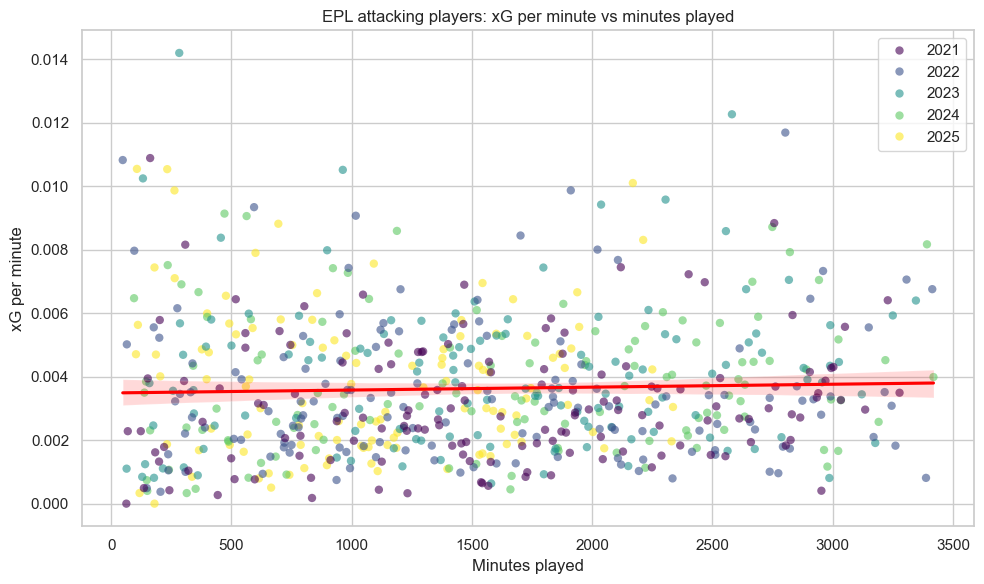

In [6]:
# Plotly scatter: xG per minute vs minutes played for attacking players

fig_xg = px.scatter(
    attacking,
    x="time",
    y="xG_per_min",
    color="season",
    hover_name="player_name",
    hover_data={
        "team_title": True,
        "league": True,
        "time": True,
        "xG": True,
        "xG_per_min": ':.4f',
    },
    trendline="ols",
    trendline_color_override="red",
    title="Top-5 leagues attacking players: xG per minute vs minutes played",
    labels={
        "time": "Minutes played",
        "xG_per_min": "xG per minute",
    },
)

fig_xg.show()

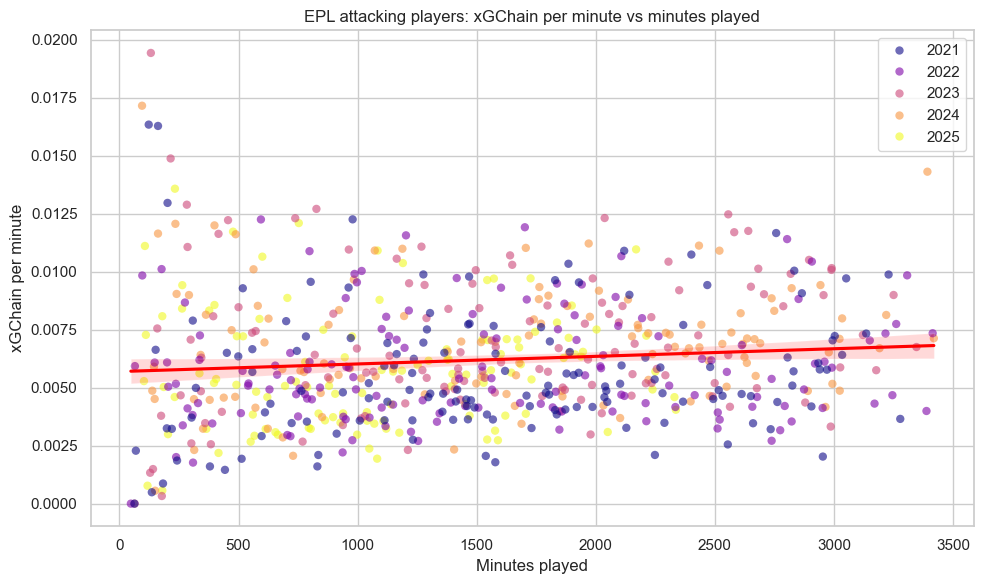

In [7]:
# Plotly scatter: xGChain per minute vs minutes played for attacking players

fig_xgchain = px.scatter(
    attacking,
    x="time",
    y="xGChain_per_min",
    color="season",
    hover_name="player_name",
    hover_data={
        "team_title": True,
        "league": True,
        "time": True,
        "xGChain": True,
        "xGChain_per_min": ':.4f',
    },
    trendline="ols",
    trendline_color_override="red",
    title="Top-5 leagues attacking players: xGChain per minute vs minutes played",
    labels={
        "time": "Minutes played",
        "xGChain_per_min": "xGChain per minute",
    },
)

fig_xgchain.show()